Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn
===

Your task:

1. Data Preparation:
Download and explore the US Superstore data.
Perform basic data cleaning and preprocessing.


2. Data Visualization with Matplotlib:
Create an interactive line chart to show sales trends over the years.
Build an interactive map to visualize sales distribution by country.


3. Data Visualization with Seaborn:
Use Seaborn to generate a bar chart showing top 10 products by sales.
Create a scatter plot to analyze the relationship between profit and discount.


4. Comparative Analysis:
Compare the insights gained from Matplotlib and Seaborn visualizations.
Document your observations about the ease of use and effectiveness of both tools.


5. Code and Insights:
Write clear, well-documented Python code.
Include your analysis and insights as comments or markdown cells in your Jupyter notebook.


**Data Preparation:**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
df = pd.read_excel('../Exercises/US_Superstore_data.xls')


In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year

df.dropna(subset=['Sales', 'Profit', 'Order Date'], inplace=True)

print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Region  \
0      Claire Gute   Consumer  United States        Henderson  ...  South   
1      Claire Gute   Consumer  United States        Henderson  ...  South   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   West   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   

        Product ID         Category Sub-Category  \
0  FUR-BO-

**Data Visualization with Matplotlib:**

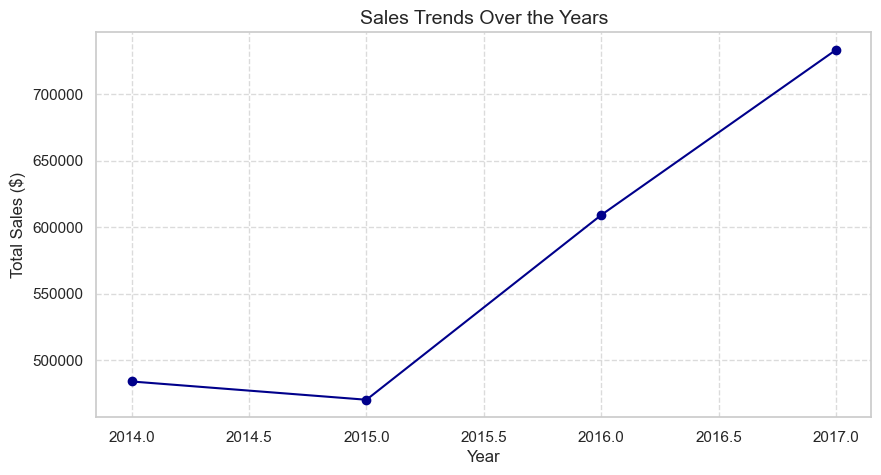

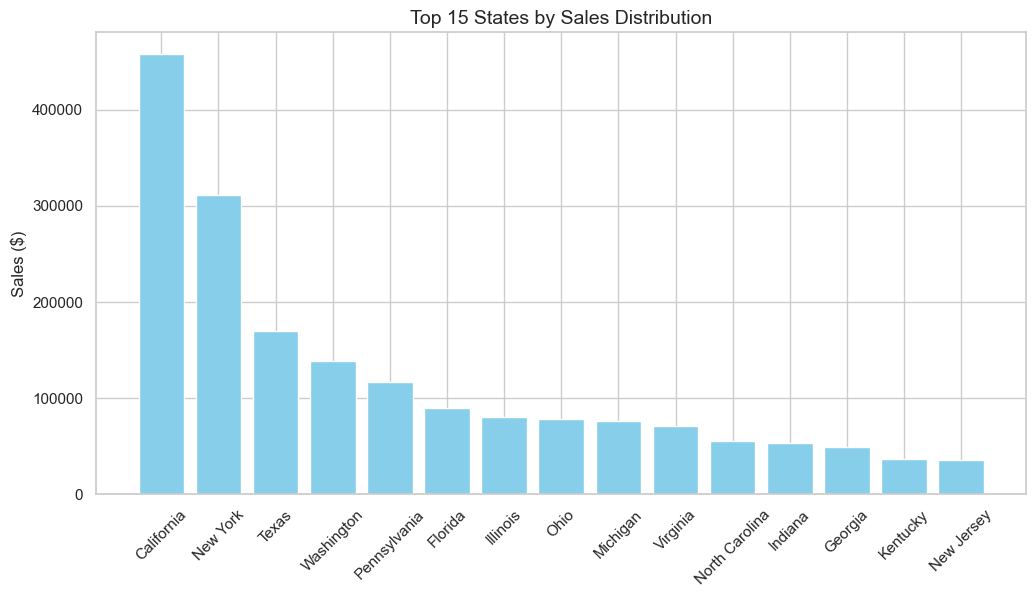

In [26]:
# --- Line Chart: Sales Trends ----
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', linestyle='-', color='darkblue')
plt.title('Sales Trends Over the Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Visualization: Sales Distribution by State ---

state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(state_sales.index, state_sales.values, color='skyblue')
plt.title('Top 15 States by Sales Distribution', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Sales ($)')
plt.show()

**Data Visualization with Seaborn:**

/var/folders/11/01wml45d32l3bgdl2z4gyjth0000gn/T/ipykernel_26415/3066183614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_products, x='Sales', y='Product Name', palette='viridis')


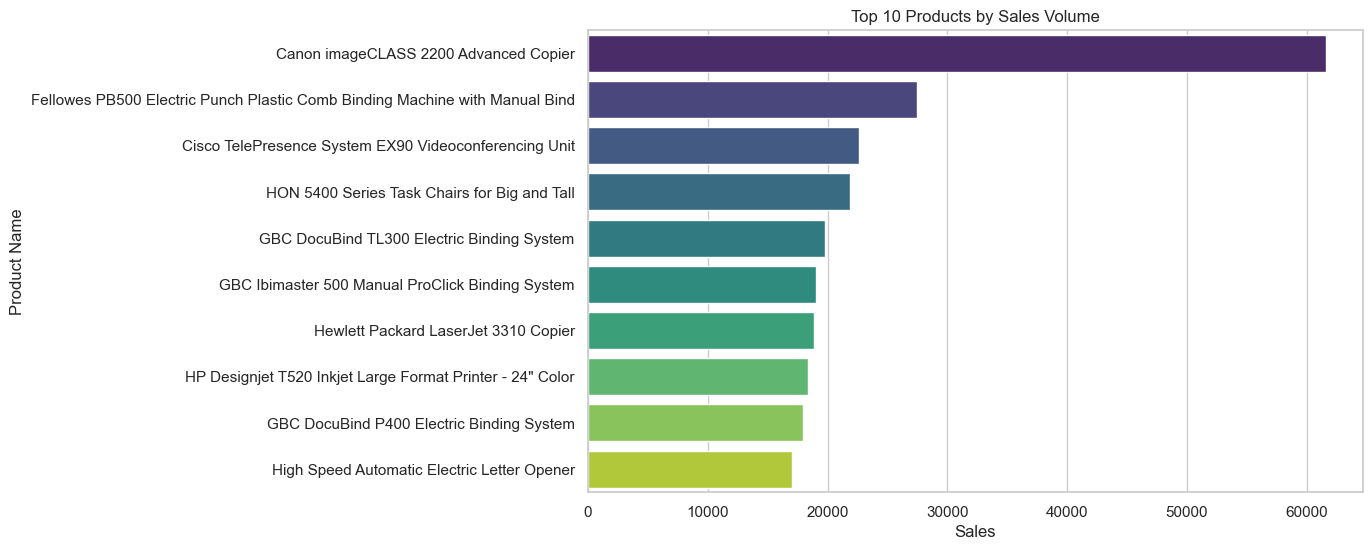

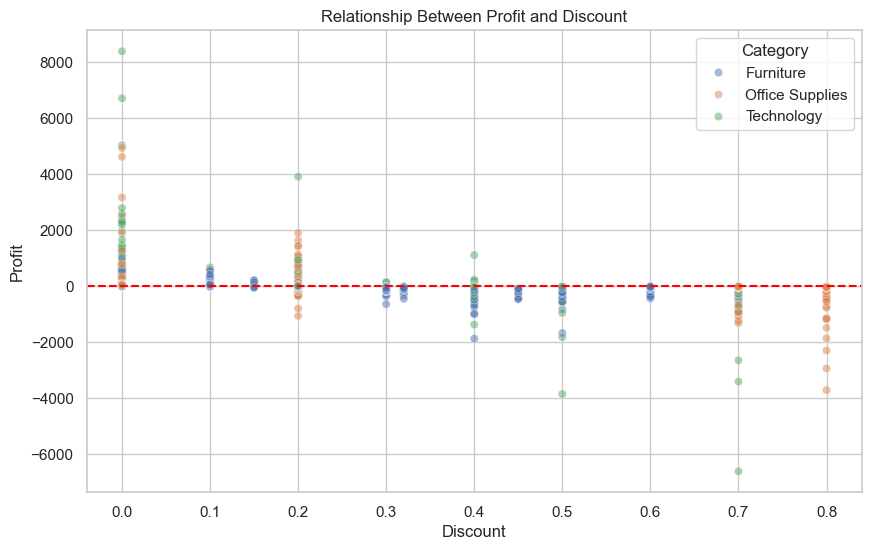

In [27]:
# --- Bar Chart: Top 10 Products by Sales ---
top_10_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_products, x='Sales', y='Product Name', palette='viridis')
plt.title('Top 10 Products by Sales Volume')
plt.show()

# --- Scatter Plot: Profit vs. Discount ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5)
plt.title('Relationship Between Profit and Discount')
plt.axhline(0, color='red', linestyle='--') 
plt.show()

**Comparative Analysis:**

**Matplotlib:**

 Great for basic control and "building" the chart layout. It is the core engine, but requires more lines of code to make things like legends and colors look modern.

**Seaborn:**

 Much more efficient for "Elegant" data presentation. Commands like 'hue' in the scatter plot automatically handle complex grouping and color coding that would take many more lines in Matplotlib. It is easier to use for statistical relationships.

**Code and Insights:**


**Analysis & Insights:**

**Sales Momentum**: The store experienced significant growth between 2016 and 2017, with revenue jumping from approximately 609k dollars to 733k dollars.

**The "Discount Trap"**: Looking at the scatter plot, there is a clear threshold at 30% (0.3) discount. Orders with discounts of 30% or higher almost consistently result in a net loss for the company.

**Regional Powerhouse**: California and New York drive the vast majority of revenue. Sales strategies should be optimized to maintain dominance in these states while investigating lower performance in other regions.

**Star Product:** The "Canon imageCLASS 2200 Advanced Copier" is the top-performing product by a massive margin, generating over $60k in sales. This indicates a high demand for premium office technology.